Esercizio:

Il 'Cropping' Chirurgico e ConversioneTraccia

Uno dei compiti più comuni nel pre-processing per il Deep Learning è il ritaglio (cropping) di una zona  specifica dell'immagine per portarla a una dimensione fissa (es. 244x244)

Scrivi uno script che
- carichi un'immmagine casuale dall'URL
- identifichi il centro dell'immagine
- utilizzi lo slicing di NumPy per estrarre un quadrato centrale di 300 imes 300 pixel
- salvi il risultato finale in formato PNG assicurandoti di non invertire i canali di colore.

Download immagine da: https://picsum.photos/1200/800...
Dimensioni originali: Altezza 800px, Larghezza 1200px, Canali 3
Nuove dimensioni dopo il crop: (300, 300, 3)
Risultato salvato con successo come: centro_chirurgico_300.png


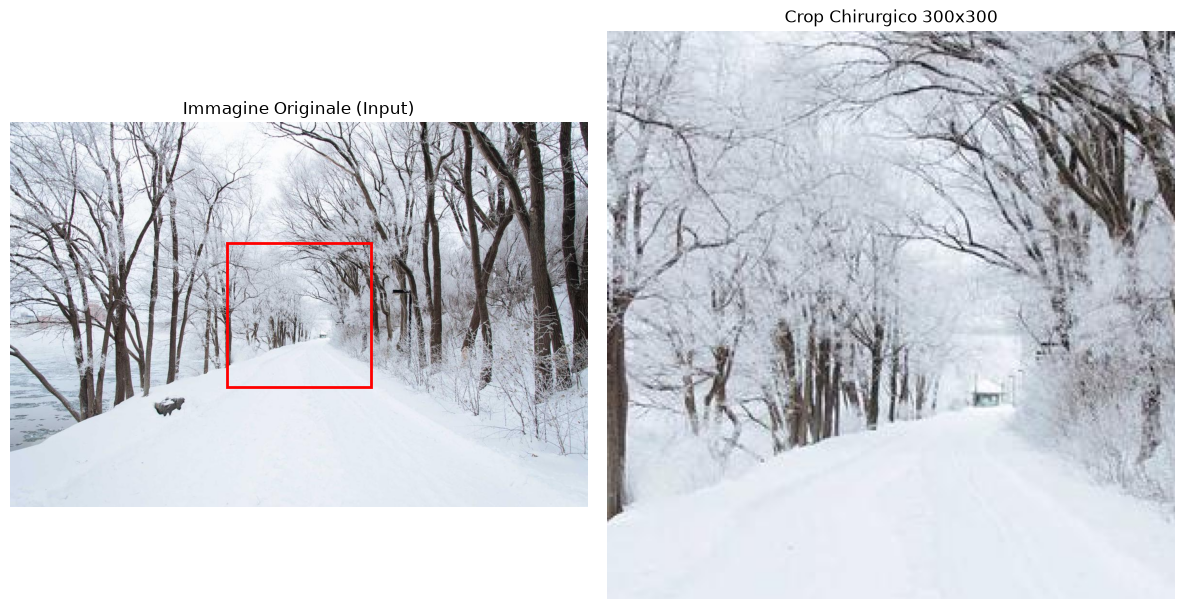

In [1]:
import os

# --- 1. CONFIGURAZIONE BACKEND ---
# Keras 3 è agnostico: impostiamo PyTorch come motore di calcolo prima dell'import.
# Teoria: Il backend gestisce come i tensori vengono allocati in memoria (GPU/CPU).
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import keras  # Utilizziamo Keras 3 per la standardizzazione dell'output

def surgical_cropping_workshop():
    """
    Esegue un ritaglio centrale preciso utilizzando lo slicing di NumPy.
    Teoria: Il cropping è una trasformazione geometrica che preserva la risoluzione locale
    ma riduce il campo visivo (Field of View), essenziale per standardizzare gli input delle CNN.
    """
    
    # --- 2. ACQUISIZIONE DATI ---
    # Scarichiamo un'immagine ad alta risoluzione (1200x800)
    url = "https://picsum.photos/1200/800"
    print(f"Download immagine da: {url}...")
    response = requests.get(url)
    
    # Carichiamo con Pillow per garantire il formato RGB standard
    img_pil = Image.open(BytesIO(response.content))
    # Convertiamo in NumPy array: l'immagine diventa un tensore [H, W, C]
    img_array = np.array(img_pil)
    
    # Recuperiamo le dimensioni spaziali
    # Teoria: In NumPy, shape[0] è l'Altezza (asse Y), shape[1] è la Larghezza (asse X)
    h, w, c = img_array.shape
    print(f"Dimensioni originali: Altezza {h}px, Larghezza {w}px, Canali {c}")

    # --- 3. LOGICA DI CROPPING CHIRURGICO (NumPy Slicing) ---
    # Definiamo la dimensione del target (300x300)
    crop_size = 300
    
    # Identifichiamo il centro geometrico dell'immagine
    # Teoria: Usiamo la divisione intera (//) perché gli indici dei pixel devono essere numeri interi
    center_y, center_x = h // 2, w // 2
    
    # Calcoliamo le coordinate di inizio e fine per il ritaglio
    # Sottraiamo e sommiamo metà della dimensione target dal centro
    start_y = center_y - (crop_size // 2)
    end_y   = center_y + (crop_size // 2)
    start_x = center_x - (crop_size // 2)
    end_x   = center_x + (crop_size // 2)
    
    # Eseguiamo lo slicing: [y_inizio:y_fine, x_inizio:x_fine, tutti_i_canali]
    # Teoria: Lo slicing di NumPy non copia i dati in memoria (è una 'view'), 
    # rendendo questa operazione estremamente efficiente per dataset massivi.
    img_cropped = img_array[start_y:end_y, start_x:end_x, :]
    
    print(f"Nuove dimensioni dopo il crop: {img_cropped.shape}")

    # --- 4. SALVATAGGIO PROFESSIONALE (Keras 3) ---
    # Salviamo in PNG per evitare artefatti di compressione (lossless).
    # Teoria: Keras 3 save_img mantiene la coerenza dei canali RGB senza l'inversione tipica di OpenCV.
    output_filename = "centro_chirurgico_300.png"
    keras.utils.save_img(output_filename, img_cropped)
    print(f"Risultato salvato con successo come: {output_filename}")

    # --- 5. VISUALIZZAZIONE COMPARATIVA ---
    plt.figure(figsize=(12, 6))

    # Visualizzazione Immagine Originale con mirino sul centro
    plt.subplot(1, 2, 1)
    plt.title("Immagine Originale (Input)")
    plt.imshow(img_array)
    # Disegniamo un rettangolo per mostrare l'area che abbiamo "operato"
    rect = plt.Rectangle((start_x, start_y), crop_size, crop_size, 
                         linewidth=2, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)
    plt.axis('off')

    # Visualizzazione Risultato Finale
    plt.subplot(1, 2, 2)
    plt.title(f"Crop Chirurgico {crop_size}x{crop_size}")
    plt.imshow(img_cropped)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    surgical_cropping_workshop()